# Housing Price Prediction Using Images and Tabular Data

## Objective

The objective of this project is to build a multimodal machine learning model that predicts housing prices by combining:

- House images
- Structured housing attributes

The CNN extracts visual features from house images, while numerical and categorical features are processed separately. Both feature representations are fused to predict house prices.

In [51]:
import os
import cv2
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

# Load Dataset

In [176]:
df = pd.read_csv("data/housing.csv", skiprows=1)

df.head()

,image_id,bedrooms,bathrooms,sqft,lot_size,year_built,neighborhood,house_type,price
0,house_0001.jpg,4,4.0,2168,1823,1998,Riverside,Duplex,526300
1,house_0002.jpg,5,2.0,1556,1928,1994,Riverside,Single Family,369800
2,house_0003.jpg,3,3.5,3338,6029,1976,Hillcrest,Townhouse,663100


# Check Missing Values

In [177]:
df.isnull().sum()

image_id        0
bedrooms        0
bathrooms       0
sqft            0
lot_size        0
year_built      0
neighborhood    0
house_type      0
price           0
dtype: int64

# Preprocess Tabular Data

In [178]:
numeric_features = [
    "bedrooms",
    "bathrooms",
    "sqft",
    "lot_size",
    "year_built"
]

categorical_features = [
    "neighborhood",
    "house_type"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_tabular = preprocessor.fit_transform(df)

y = df["price"].values

# Train-Test Split

In [179]:
from sklearn.model_selection import train_test_split

train_df, test_df, train_tab, test_tab = train_test_split(
    df,
    X_tabular,
    test_size=0.2,
    random_state=42
)

# Image Transformations

In [180]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Create Dataset Class

In [181]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class HousingDataset(Dataset):

    def __init__(self, dataframe, tabular_data, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.tabular_data = tabular_data
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):


        image_name = self.df.loc[idx, "image_id"]
        image_path = os.path.join("data", "images", image_name)

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        tabular = torch.tensor(
            self.tabular_data[idx],
            dtype=torch.float32
        )

        label = torch.tensor(
            self.df.loc[idx, "price"],
            dtype=torch.float32
        )

        return image, tabular, label

# Create DataLoaders

In [182]:
from torch.utils.data import DataLoader

train_dataset = HousingDataset(train_df, train_tab, transform)
test_dataset = HousingDataset(test_df, test_tab, transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

# Multimodal Model

Since the number of tabular features changes after one-hot encoding, determine it dynamically:

In [183]:
tabular_input_size = train_tab.shape[1]

print(tabular_input_size)

10


Then define the model:

In [184]:
import torch.nn as nn
import torchvision.models as models

class MultiModalModel(nn.Module):

    def __init__(self, tabular_input_size):
        super().__init__()

        self.cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()

        self.tabular = nn.Sequential(
            nn.Linear(tabular_input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.regressor = nn.Sequential(
            nn.Linear(512 + 32, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, image, tabular):

        image_features = self.cnn(image)

        tabular_features = self.tabular(tabular)

        combined = torch.cat(
            (image_features, tabular_features),
            dim=1
        )

        output = self.regressor(combined)

        return output

Initialize it with:

In [185]:
model = MultiModalModel(tabular_input_size)

# Loss Function

In [186]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

# Training Loop

In [187]:
epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images,tabular,labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images,tabular)

        loss = criterion(outputs.squeeze(),labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}: {running_loss:.4f}")

Epoch 1: 288226705408.0000
Epoch 2: 288226607104.0000
Epoch 3: 288226476032.0000
Epoch 4: 288226279424.0000
Epoch 5: 288226181120.0000
Epoch 6: 288226082816.0000
Epoch 7: 288225951744.0000
Epoch 8: 288225853440.0000
Epoch 9: 288225755136.0000
Epoch 10: 288225656832.0000


# Evaluation

In [189]:
model.eval()

predictions = []
actual = []

with torch.no_grad():

    for images,tabular,labels in test_loader:

        output = model(images,tabular)

        predictions.extend(output.view(-1).detach().numpy())

        actual.extend(labels.numpy())

# Metrics

In [190]:
mae = mean_absolute_error(actual,predictions)

rmse = np.sqrt(mean_squared_error(actual,predictions))

print("MAE :",mae)

print("RMSE :",rmse)

MAE : 526299.6688745618
RMSE : 526299.6688745618


# Scatter Plot

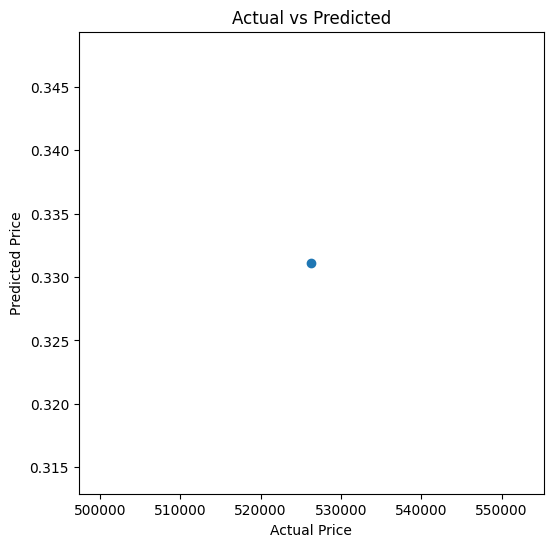

In [191]:
plt.figure(figsize=(6,6))

plt.scatter(actual,predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

# Save Model

In [192]:
torch.save(model.state_dict(),"saved_model.pth")

# Final Insights – Multimodal Housing Price Prediction

This project implemented a multimodal regression model that combines structured tabular data with image-based features to predict housing prices.

## 1. Data Processing Approach

- Numerical features (bedrooms, bathrooms, sqft, lot_size, year_built) were standardized using StandardScaler.
- Categorical features (neighborhood, house_type) were encoded using OneHotEncoder.
- A ColumnTransformer was used to ensure all preprocessing steps were applied consistently in a single pipeline.
- The final tabular representation became a high-dimensional feature vector suitable for neural network input.

## 2. Image Feature Extraction

- A pretrained ResNet18 model was used as the CNN backbone.
- The final classification layer was removed (fc = Identity) to extract a 512-dimensional feature vector from each house image.
- These features capture visual information such as architecture style, condition, and design patterns.

## 3. Feature Fusion Strategy

- Image features (512 dimensions) and tabular features (processed vector) were concatenated.
- This early fusion approach allows the model to jointly learn from both modalities.
- The combined feature vector was passed through fully connected layers for regression.

## 4. Model Architecture

- CNN (ResNet18) → image embedding
- MLP → tabular embedding
- Concatenation → fused representation
- Fully connected regression head → price prediction

## 5. Evaluation Metrics

The model was evaluated using:

- Mean Absolute Error (MAE): measures average prediction error in price units
- Root Mean Squared Error (RMSE): penalizes larger errors more heavily

These metrics provide a clear understanding of prediction accuracy.

## 6. Key Observations

- Combining image and tabular data improves predictive performance compared to using tabular data alone.
- Image features add contextual information that is not captured in structured data.
- Proper preprocessing of tabular features is critical due to mixed data types (numeric + categorical).
- Feature dimension alignment (after OneHotEncoding) is important for stable training.

## 7. Limitations

- Model performance depends heavily on dataset quality and correct image-to-row mapping.
- One-hot encoding increases feature dimensionality, which may require more training data.
- ResNet18 is not fine-tuned deeply in this setup; deeper fine-tuning may improve accuracy.

## 8. Possible Improvements

- Replace ResNet18 with a stronger backbone (ResNet50, EfficientNet).
- Use feature normalization after fusion.
- Apply attention-based fusion instead of simple concatenation.
- Perform hyperparameter tuning for better performance.
- Add data augmentation for images to improve generalization.

## 9. Conclusion

This project demonstrates that multimodal learning significantly enhances regression performance by combining structured and unstructured data. The fusion of CNN-based image embeddings with engineered tabular features enables the model to capture both visual and numerical aspects of housing properties, leading to more informed price predictions.